Universidade do Vale do Itajaí  
Processamento Digital de Sinais  
Docente: Walter Antônio Gotijo  
Acadêmico: Henry José  
Curso: Engenharia de Computação 8º Semestre  


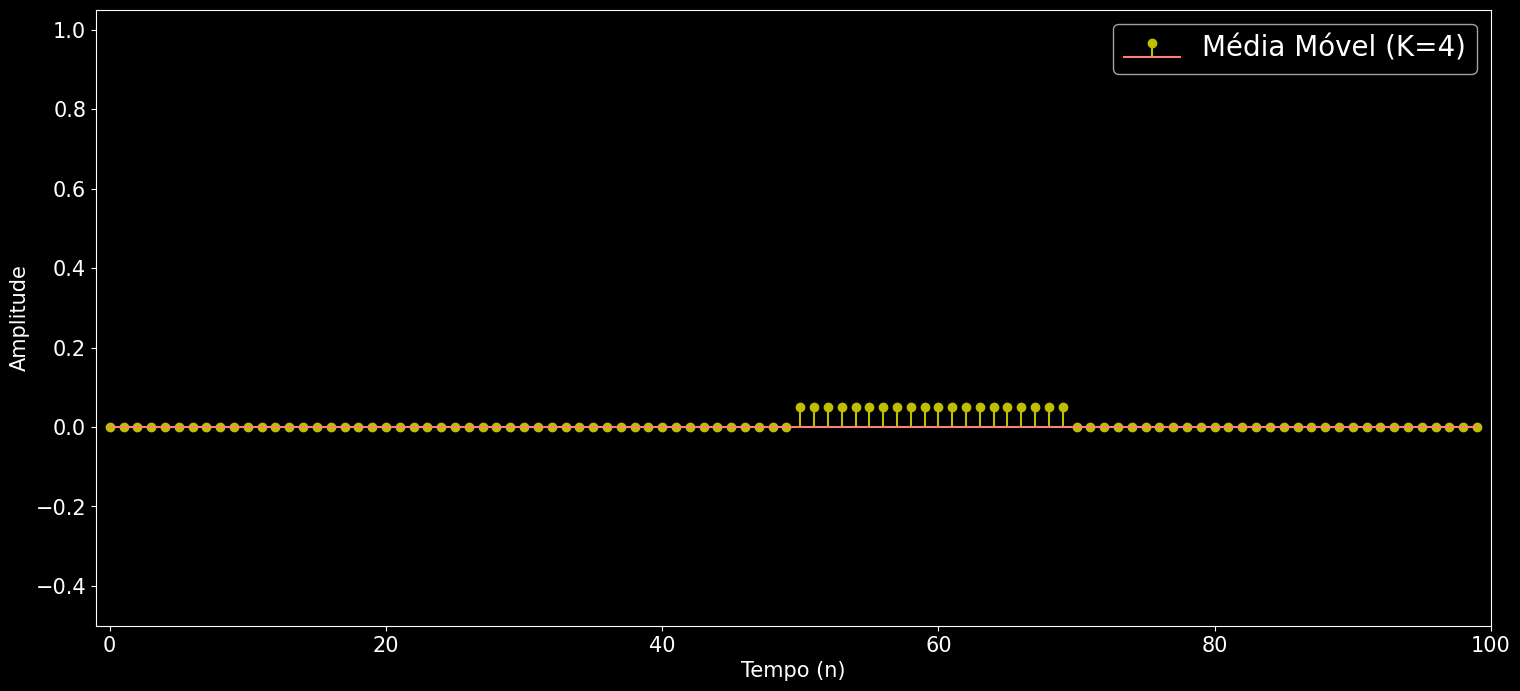

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

K = 20

n = []
#input_data = [2, 3, 5, 8, 4, 10, 12]
input_data = []
for i in range(-50,50):
    if i == 0:
        input_data.append(1)
    else:
        input_data.append(0)

amostras = []
y = []

for i in input_data:
    n.append(len(n))
    amostras.append(i)
    
    ultimas_amostras = amostras[-K:]
    
    soma_atual = np.sum(ultimas_amostras)
    y.append(soma_atual / K)

# Configuração do gráfico
plt.figure(figsize=(18, 8))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

# Plotando o gráfico de hastes (Stem plot)
plt.stem(n, y, 'yo', label='Média Móvel (K=4)')

# Ajuste dos limites para os dados atuais (0 a 6 no eixo X, amplitudes maiores que 1.2)
plt.ylim(-0.5, max(y) + 1)
plt.xlim(-1, len(input_data))

plt.xlabel('Tempo (n)', fontsize=15)
plt.ylabel('Amplitude', fontsize=15)
plt.legend(fontsize=20)
plt.show()


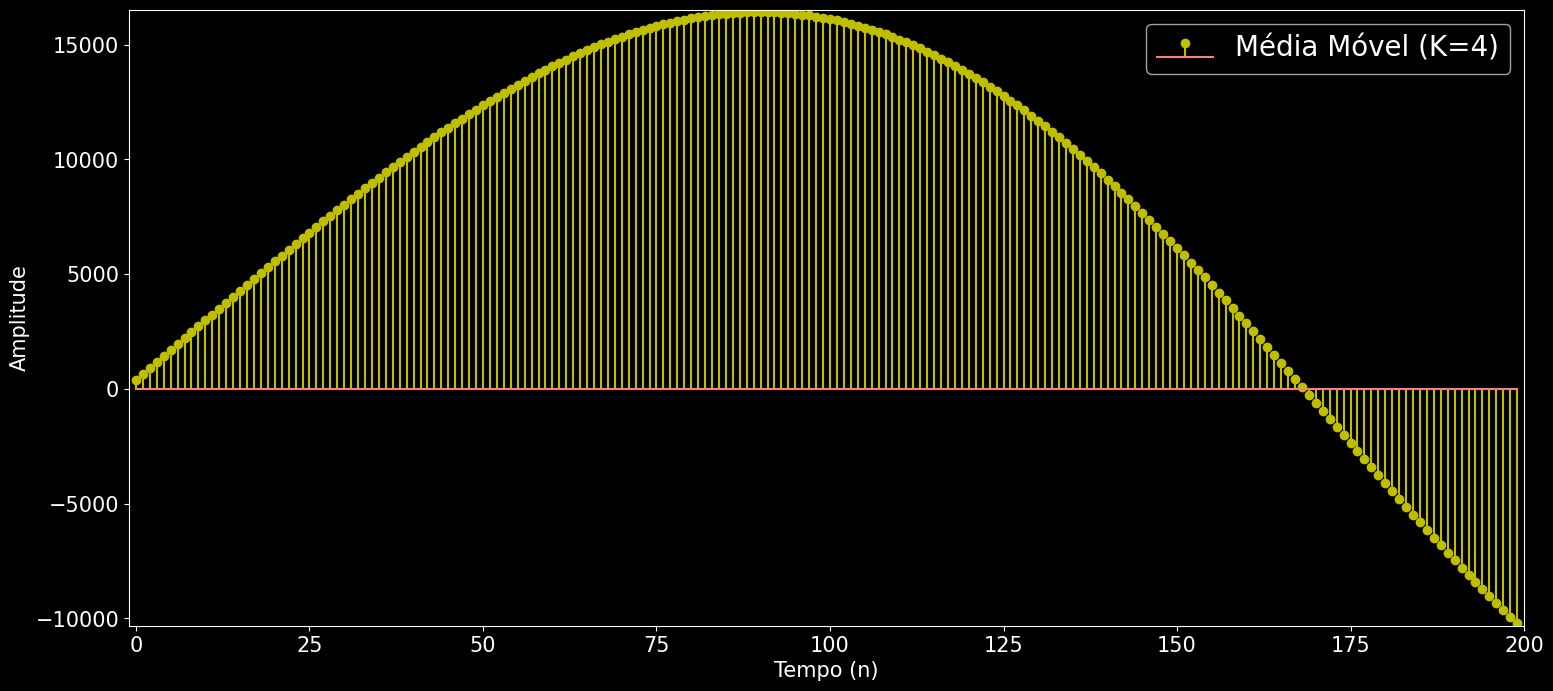

In [41]:
# 1. Configurações iniciais
taxaAmostragem = 16000
K = 4  # Tamanho da janela da Média Móvel

# 2. Carregar o arquivo PCM diretamente para um array NumPy
audio_array = np.fromfile("sweep_20_3k4.pcm", dtype=np.int16)

# Ouvir o áudio no Jupyter Notebook
display(Audio(audio_array, rate=taxaAmostragem))

# 3. Aplicar Média Móvel de forma ultra rápida (Sem usar loops 'for')
# Usamos a convolução que faz exatamente o cálculo da média móvel em blocos
janela = np.ones(K) / K
y = np.convolve(audio_array, janela, mode='valid')

# Criar o vetor de tempo/amostras (n) correspondente ao tamanho do resultado y
n = np.arange(len(y))

# 4. Configuração do gráfico
plt.figure(figsize=(18, 8))
plt.style.use('dark_background')  # Corrigido: adicionado 'plt.'
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

# ATENÇÃO: Áudios longos travam o 'plt.stem'. 
# Se o gráfico ficar em branco ou travar, use: plt.plot(n[:500], y[:500], 'y', label='Média Móvel')
# Abaixo plotamos apenas as primeiras 200 amostras para o gráfico de hastes funcionar bem:
limite_amostras = 200
plt.stem(n[:limite_amostras], y[:limite_amostras], 'yo', label=f'Média Móvel (K={K})')

# Ajuste automático dos limites dos eixos
plt.ylim(min(y[:limite_amostras]) - 100, max(y[:limite_amostras]) + 100)
plt.xlim(-1, limite_amostras)

plt.xlabel('Tempo (n)', fontsize=15)
plt.ylabel('Amplitude', fontsize=15)
plt.legend(fontsize=20)
plt.show()